# Geospatial Data Science - EEPS 440/460

# Lecture 24

# Convolutional Neural Networks II

---

U-Net is a specialized convolutional neural network (CNN) architecture designed specifically for image segmentation tasks, where the goal is to classify each pixel in an image into a specific category. 

Unlike traditional CNNs, which are often used for tasks like image classification (e.g., determining whether an image contains a cat or a dog), U-Net focuses on understanding the spatial structure of an image and producing a pixel-wise output.

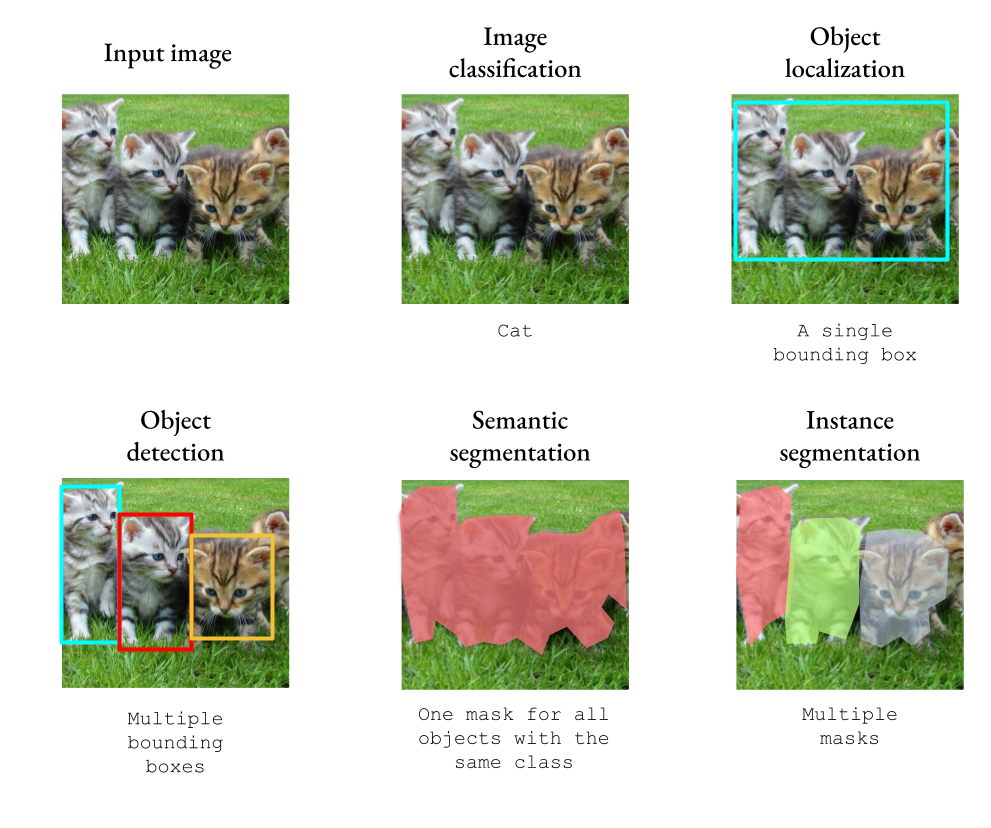



### Key Features of U-Net:
1. **Encoder-Decoder Architecture**:
    - The U-Net consists of two main parts: an encoder (contracting path) and a decoder (expanding path).
    - The encoder is similar to a traditional CNN, where the image is passed through a series of convolutional and pooling layers to extract high-level features while reducing spatial dimensions.
    - The decoder gradually upsamples the feature maps to reconstruct the original image size, enabling pixel-level predictions.

2. **Skip Connections**:
    - One of the unique aspects of U-Net is the use of skip connections, which directly connect layers in the encoder to corresponding layers in the decoder.
    - These connections help preserve fine-grained spatial details that might be lost during the downsampling process in the encoder.
    - By combining high-level features from the encoder with low-level details, U-Net achieves precise localization of features.

3. **Output**:
    - The final layer of U-Net produces a segmentation map, where each pixel is assigned a probability of belonging to a specific class (e.g., building, road, vegetation).
    
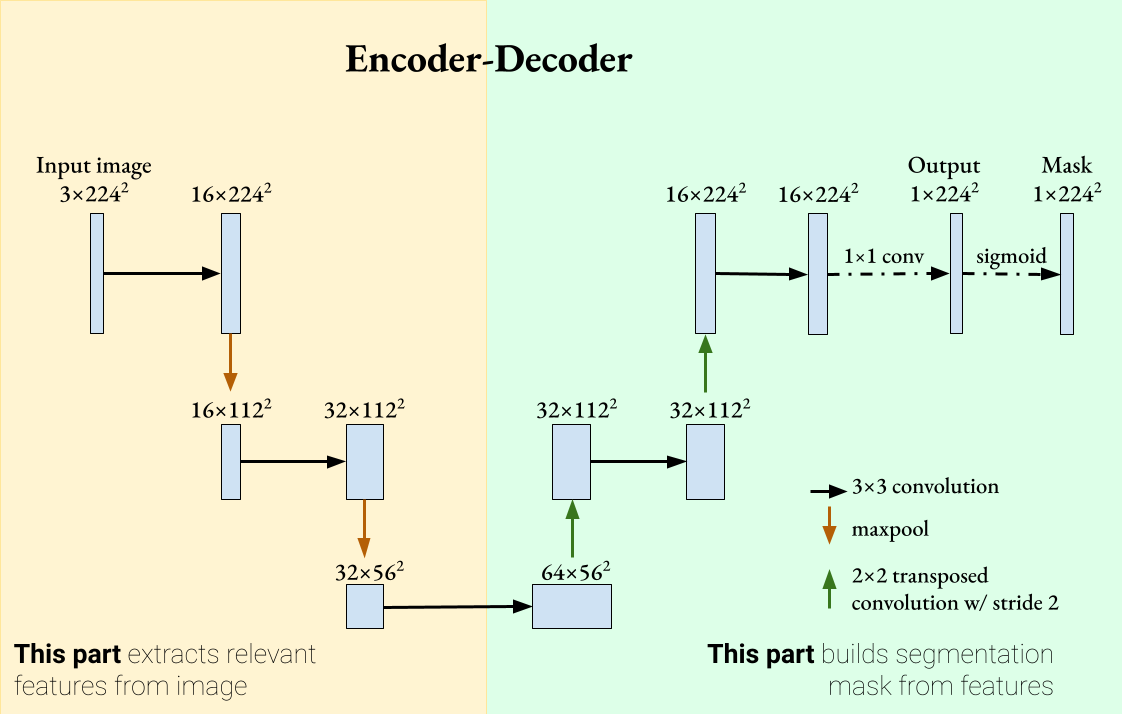

### Why U-Net is Ideal for Segmentation:
- **Localization and Context**: 
    -  Encoder captures the context of the image (what is in the image)
    -  Decoder ensures precise localization (where it is in the image).
- **Efficient Training**: 
    -   U-Net is designed to work well even with a limited amount of training data --> suitable for applications where labeled data is scarce.
- **Flexibility**: 
    -   U-Net can be adapted for binary segmentation (e.g., building vs. non-building) or multi-class segmentation (e.g., land cover classification with multiple categories).

### Applications in Geospatial Analysis:
In geospatial applications, U-Net is widely used to analyze high-resolution aerial or satellite imagery. Some common use cases include:
- **Land Cover Classification**: Identifying different types of land use, such as forests, water bodies, and urban areas.
- **Building Footprint Extraction**: Detecting and segmenting buildings in urban areas for urban planning and development.
- **Waterbody Detection**: Mapping rivers, lakes, flood areas, and other water features for environmental monitoring.
- **Urban Boundary Delineation**: Identifying the boundaries of urban areas to study urban growth and development.
- **Disaster Management**: Assessing damage after natural disasters, such as floods or earthquakes, by segmenting affected areas.

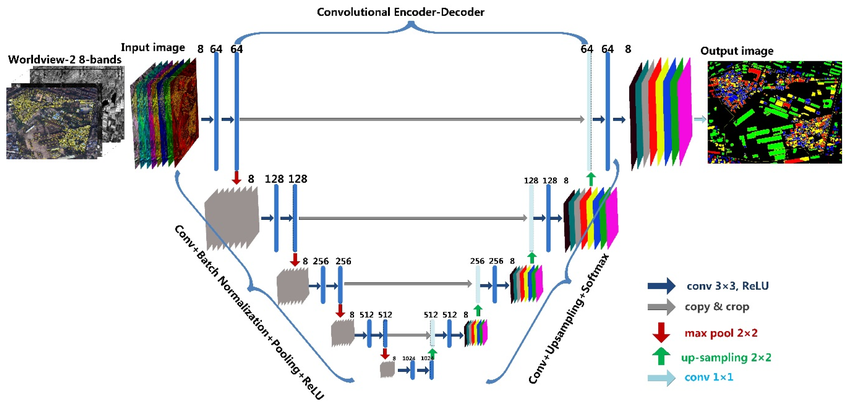

# Building Segmentation with U-Net using the Inria Aerial Dataset

### The Inria Aerial Image Labeling addresses a core topic in remote sensing: the automatic pixelwise labeling of aerial imagery (https://project.inria.fr/aerialimagelabeling/)

### Dataset features:
- Coverage of 810 km² (405 km² for training and 405 km² for testing)
- Aerial orthorectified color imagery with a spatial resolution of 0.3 m
- Ground truth data for two semantic classes: building and not building (publicly disclosed only for the training subset)
- The images cover dissimilar urban settlements, ranging from densely populated areas (e.g., San Francisco’s financial district) to alpine towns (e.g,. Lienz in Austrian Tyrol).

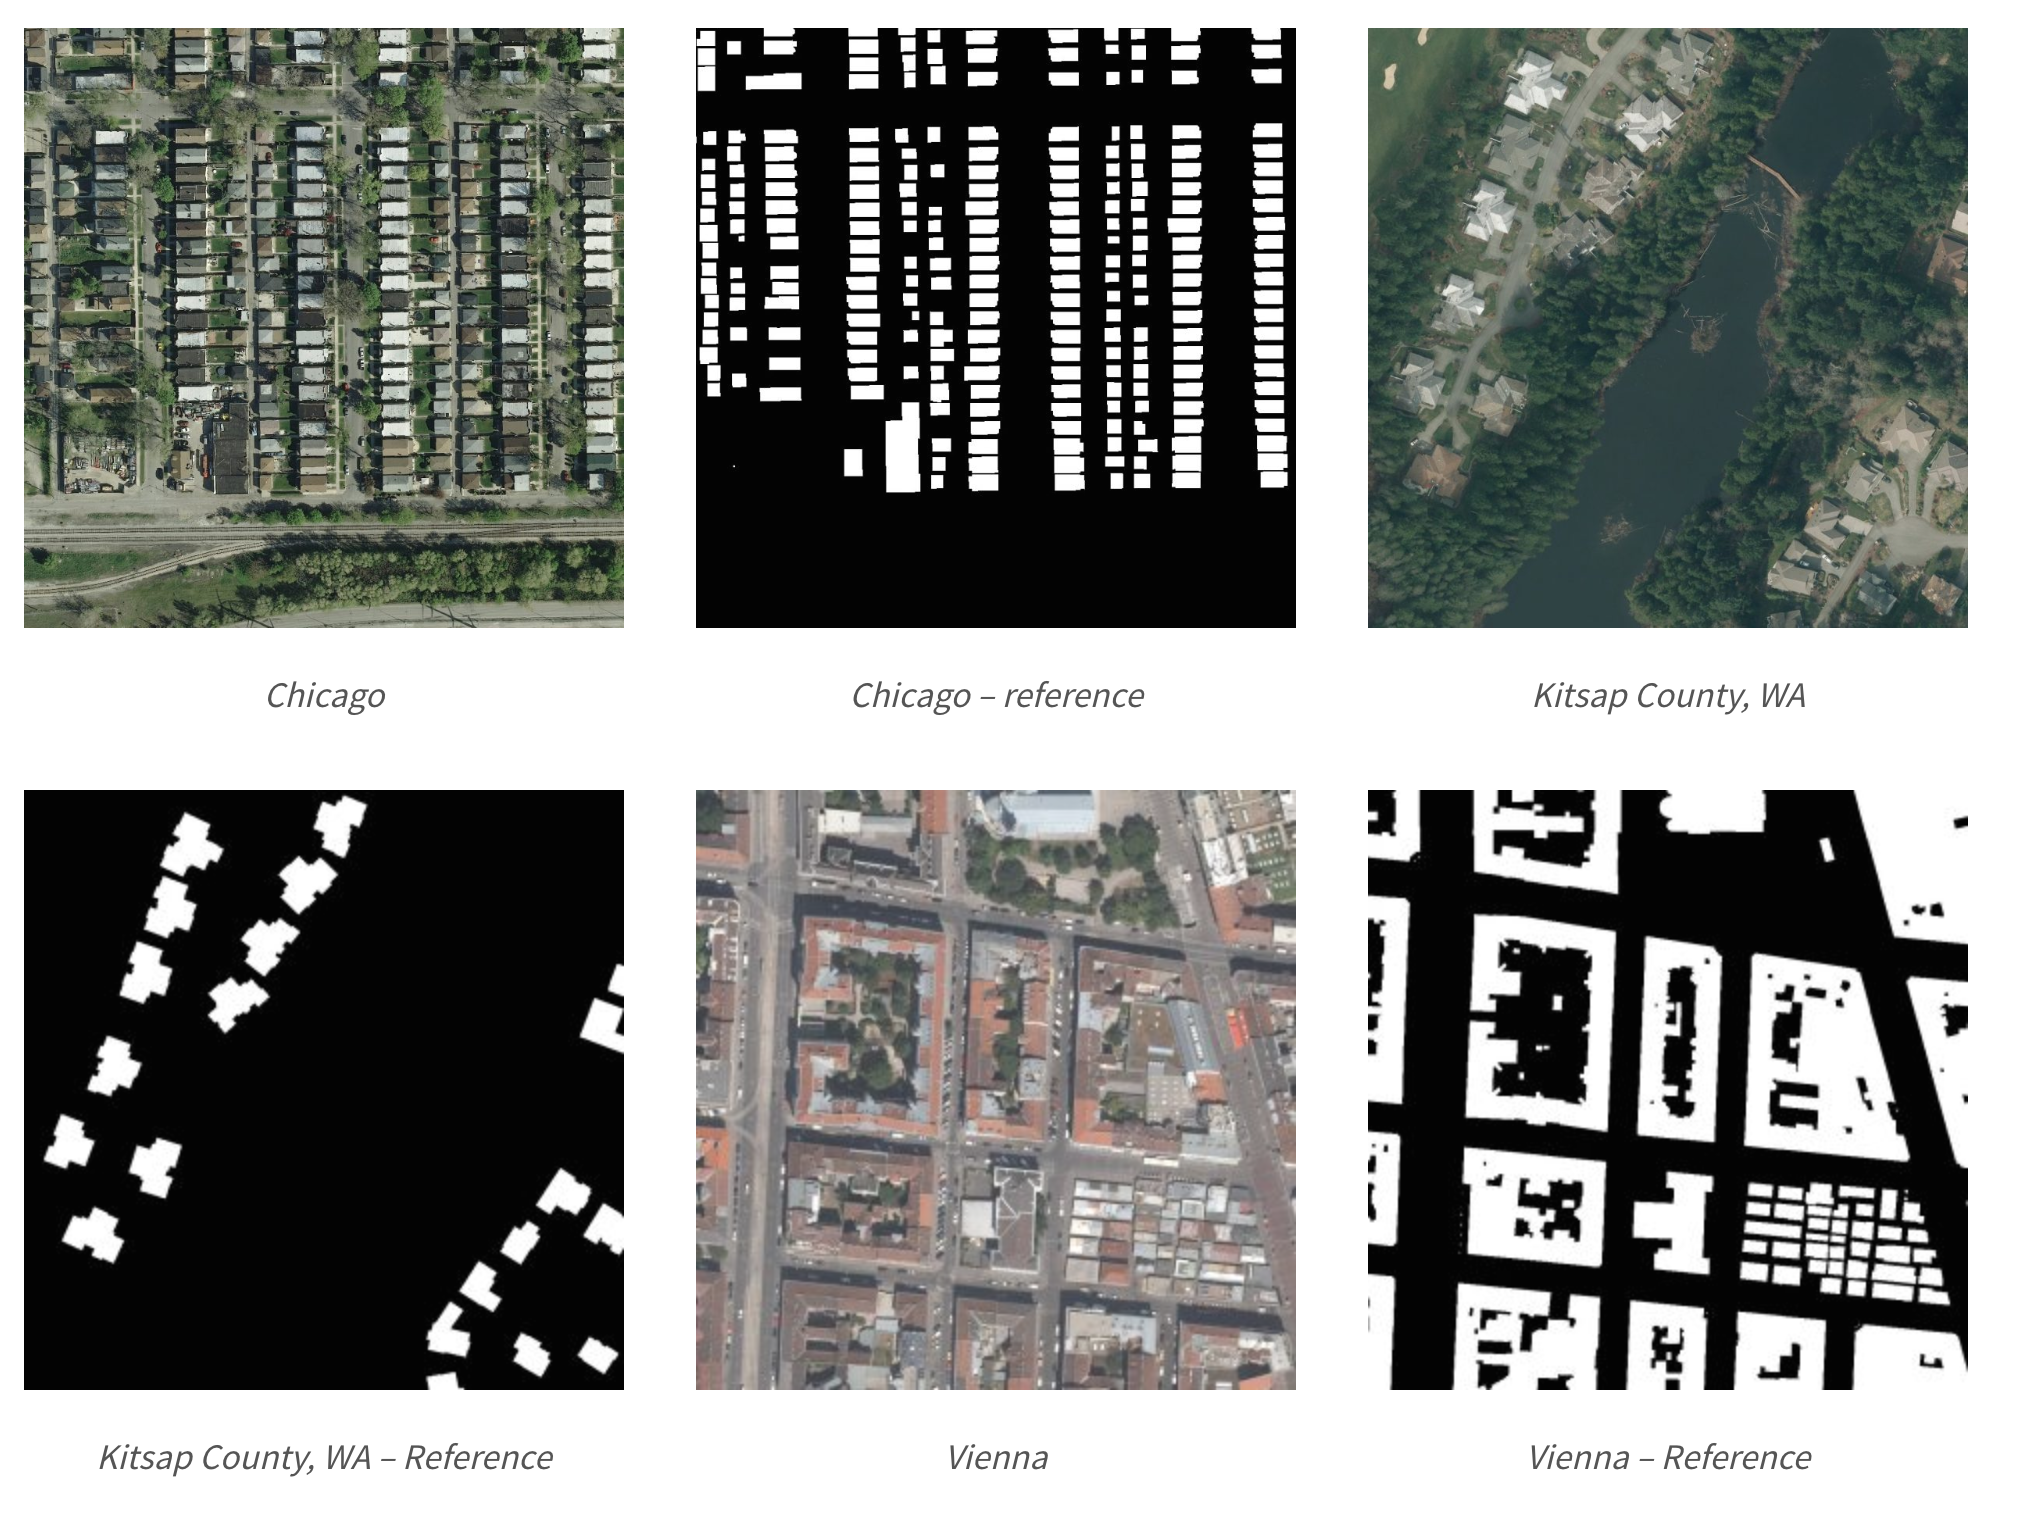

Emmanuel Maggiori, Yuliya Tarabalka, Guillaume Charpiat and Pierre Alliez. “Can Semantic Labeling Methods Generalize to Any City? The Inria Aerial Image Labeling Benchmark”. IEEE International Geoscience and Remote Sensing Symposium (IGARSS). 2017.

## Step 1: Data Preparation - Patching Inria Dataset

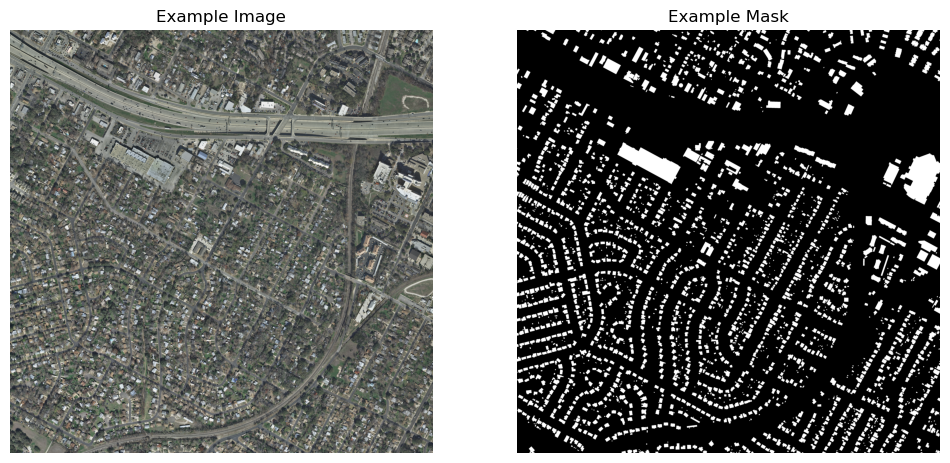

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load example image and mask
example_image_path = "../data/inria/AerialImageDataset/train/images/austin1.tif"
example_mask_path = "../data/inria/AerialImageDataset/train/gt/austin1.tif"

example_image = np.array(Image.open(example_image_path))
example_mask = np.array(Image.open(example_mask_path))

# Plot the image and mask
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(example_image)
plt.title("Example Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(example_mask, cmap="gray")
plt.title("Example Mask")
plt.axis("off")

plt.show()

### Let's create traning samples (patched) from the image and mask

Patches are smaller, localized regions or sub-images extracted from the larger image. This process can be thought of as sampling the image into smaller, more manageable pieces.

The purpose of creating patches is to focus on specific areas of the image rather than processing the entire image at once. 

This is especially useful in CNNs, where the network learns to identify patterns, textures, or features within localized regions. 

By breaking the image into patches, the model can analyze these smaller sections independently, which can improve computational efficiency and help the network generalize better.

Creating patches can also help augment the dataset by generating multiple training samples from a single image, which is beneficial when working with limited data.

In [4]:
import os
import numpy as np
from PIL import Image
from glob import glob

def create_patches(image_path, mask_path, patch_size=256, stride=256, save_dir="patches"):
    # Create directories to save the image and mask patches
    os.makedirs(f"{save_dir}/images", exist_ok=True)
    os.makedirs(f"{save_dir}/masks", exist_ok=True)

    # Get the list of image and mask files
    image_files = sorted(glob(image_path))
    mask_files = sorted(glob(mask_path))

    total_count = 0  # Initialize a counter for the total number of patches
    # Load the input image and mask as numpy arrays
    for image_file, mask_file in zip(image_files, mask_files):

        img = np.array(Image.open(image_file))  # Load the satellite image
        msk = np.array(Image.open(mask_file))  # Load the corresponding mask

        # Get the height and width of the input image
        h, w = img.shape[:2]
    
        count = 0  # Initialize a counter for naming the patches

        # Loop through the image and mask to extract patches
        # The step size is determined by the stride parameter
        for i in range(0, h - patch_size + 1, stride):  # Iterate over rows
            for j in range(0, w - patch_size + 1, stride):  # Iterate over columns
            
                # Extract a patch of size (patch_size x patch_size) from the image
                img_patch = img[i:i+patch_size, j:j+patch_size]
                # Extract the corresponding patch from the mask
                msk_patch = msk[i:i+patch_size, j:j+patch_size]

                # Save the image patch to the "images" directory
                Image.fromarray(img_patch).save(f"{save_dir}/images/patch_{total_count}.png")
                # Save the mask patch to the "masks" directory
                Image.fromarray(msk_patch).save(f"{save_dir}/masks/patch_{total_count}.png")
                
                count += 1  # Increment the patch counter per image
                total_count += 1 # Increment the total patch counter

        print(f"Processing {image_file} and {mask_file}... {count} patches created.")
  

    # Print the total number of patches created
    print(f"Created {total_count} patches.")
    
# Uncomment the line below to test the function with sample image and mask paths
example_image_path = "../data/inria/AerialImageDataset/train/images/austin1.tif"
example_mask_path = "../data/inria/AerialImageDataset/train/gt/austin1.tif"
create_patches(example_image_path, example_mask_path)


Processing ../data/inria/AerialImageDataset/train/images/austin1.tif and ../data/inria/AerialImageDataset/train/gt/austin1.tif... 361 patches created.
Created 361 patches.


## Step 2: Load the Patches and Preprocess

In [5]:
import os
import numpy as np
from PIL import Image
from glob import glob
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

# Function to load image and mask patches from directories and preprocess them
def load_patches(img_dir, mask_dir, img_size=(256, 256)):
    # Get sorted lists of all image and mask file paths in the respective directories
    img_paths = sorted(glob(os.path.join(img_dir, "*.png")))
    mask_paths = sorted(glob(os.path.join(mask_dir, "*.png")))

    # Load and preprocess all image patches
    # Each image is resized to the specified size (default is 256x256) and normalized to [0, 1]
    X = np.array([img_to_array(load_img(p, target_size=img_size)) / 255.0 for p in img_paths])
    print('X shape', X.shape)
    
    # Load and preprocess all mask patches
    # Each mask is resized to the specified size and converted to grayscale, then normalized to [0, 1]
    y = np.array([img_to_array(load_img(p, target_size=img_size, color_mode="grayscale")) / 255.0 for p in mask_paths])
    print('y shape', y.shape)
    
    return X, y  # Return the preprocessed image and mask arrays

# Load the image and mask patches from the specified directories
X, y = load_patches("patches/images", "patches/masks")

# Split the data into training and validation sets
# 80% of the data is used for training, and 20% is used for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


X shape (361, 256, 256, 3)
y shape (361, 256, 256, 1)


### Let's plot a sample of your patched data

Training data size: (288, 256, 256, 3), Training labels size: (288, 256, 256, 1)
Validation data size: (73, 256, 256, 3), Validation labels size: (73, 256, 256, 1)


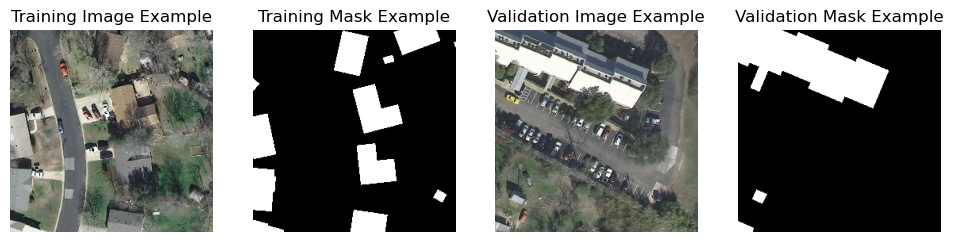

In [35]:
import matplotlib.pyplot as plt

# Print the sizes of the training and validation datasets
print(f"Training data size: {X_train.shape}, Training labels size: {y_train.shape}")
print(f"Validation data size: {X_val.shape}, Validation labels size: {y_val.shape}")

# Display an example from the training data
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(X_train[0])
plt.title("Training Image Example")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(y_train[0, :, :, 0], cmap="gray")
plt.title("Training Mask Example")
plt.axis("off")

# Display an example from the validation data
plt.subplot(1, 4, 3)
plt.imshow(X_val[1])
plt.title("Validation Image Example")
plt.axis("off")

# Display an example from the validation data
plt.subplot(1, 4, 4)
plt.imshow(y_val[1, :, :, 0], cmap="gray")
plt.title("Validation Mask Example")
plt.axis("off")

plt.show()

## Step 3: Build the U-Net Model

In [7]:
from tensorflow.keras import layers, models

# Function to build a U-Net model
def build_unet(input_shape=(256, 256, 3)):
    # Define the input layer with the specified shape
    inputs = layers.Input(shape=input_shape)

    # Encoder block 1
    # First convolutional layer with 32 filters, 3x3 kernel, ReLU activation, and same padding
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    # Second convolutional layer in the block
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    # Max pooling layer to downsample the feature map
    p1 = layers.MaxPooling2D()(c1)

    # Encoder block 2
    # First convolutional layer with 64 filters
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    # Second convolutional layer in the block
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    # Max pooling layer to further downsample the feature map
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    # Convolutional layer with 128 filters at the bottleneck of the U-Net
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    # Decoder block 1
    # Upsampling layer to increase the spatial dimensions of the feature map
    u1 = layers.UpSampling2D()(b)
    # Concatenate the upsampled feature map with the corresponding encoder block's output
    u1 = layers.Concatenate()([u1, c2])
    # First convolutional layer in the decoder block
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    # Second convolutional layer in the decoder block
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    # Decoder block 2
    # Upsampling layer to further increase the spatial dimensions
    u2 = layers.UpSampling2D()(c3)
    # Concatenate the upsampled feature map with the corresponding encoder block's output
    u2 = layers.Concatenate()([u2, c1])
    # First convolutional layer in the decoder block
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    # Second convolutional layer in the decoder block
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    # Output layer
    # Convolutional layer with 1 filter and sigmoid activation for binary segmentation
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    # Define the U-Net model
    model = models.Model(inputs, outputs)
    # Compile the model with Adam optimizer, binary cross-entropy loss, and accuracy metric
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build the U-Net model
model = build_unet()
# Print the model summary to visualize the architecture
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 32)         896       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 256, 256, 32)         9248      ['conv2d[0][0]']              
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 128, 128, 32)         0         ['conv2d_1[0][0]']            
 D)                                                                                           

2025-04-14 01:15:30.559812: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-04-14 01:15:30.559835: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-04-14 01:15:30.559842: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2025-04-14 01:15:30.559871: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-14 01:15:30.559886: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


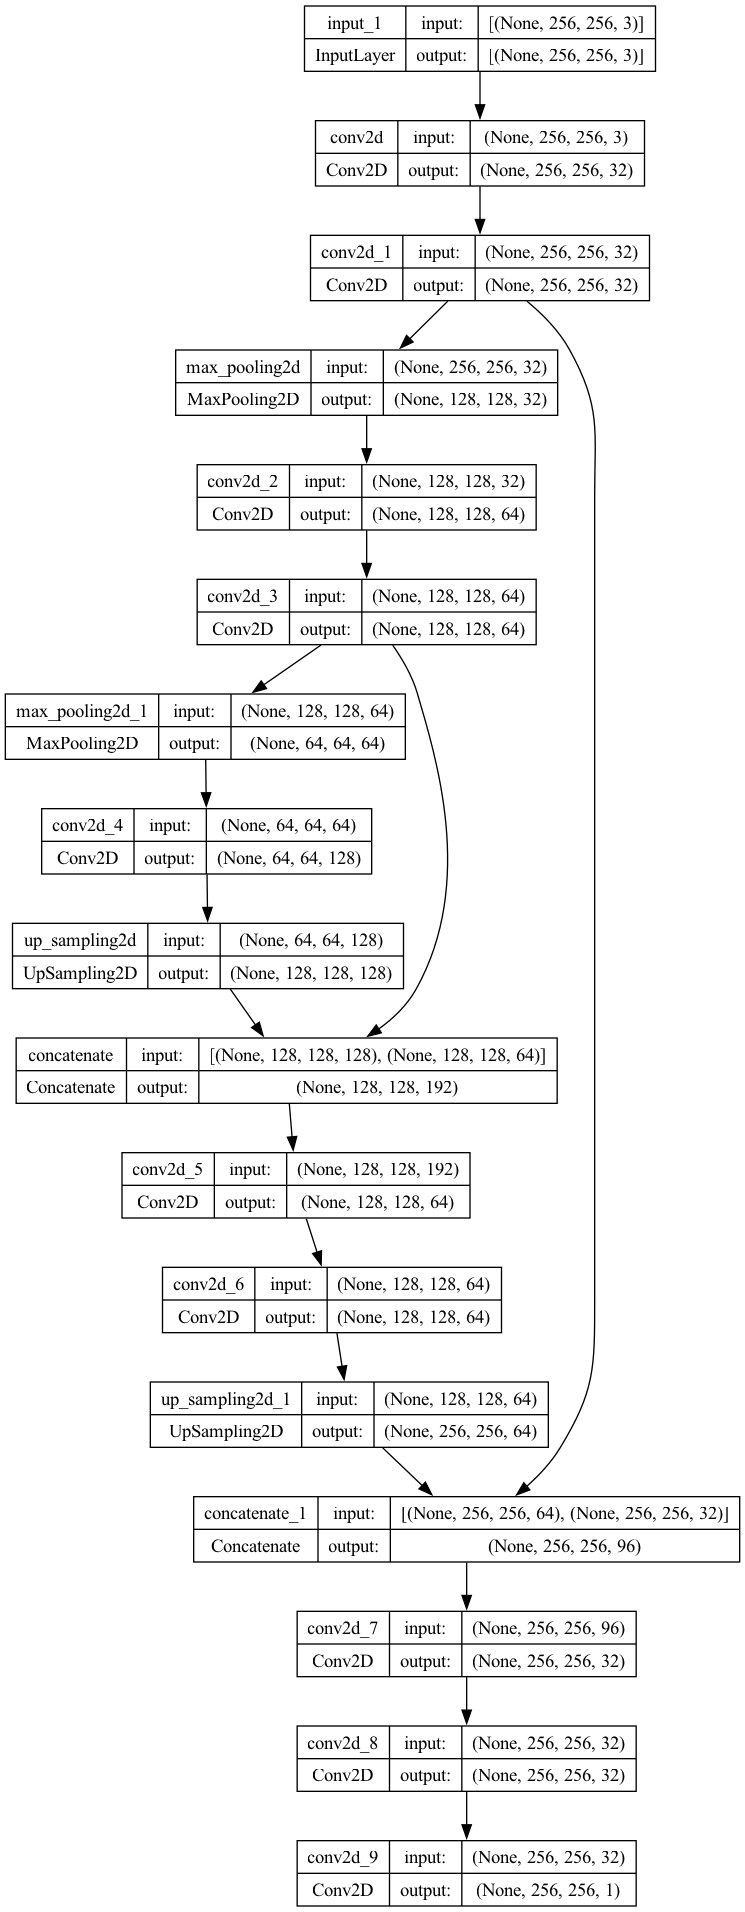

In [8]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Generate a graphic illustration of the U-Net model
plot_model(model, to_file="unet_model.png", show_shapes=True, show_layer_names=True)

# Display the generated image
Image(filename="unet_model.png", width=400, height=300)

## Step 4: Train the Model

In [9]:

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=16, shuffle=True, verbose=1)


Epoch 1/10


2025-04-14 01:15:31.290380: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


18/18 [==============================] - 6s 294ms/step - loss: 0.5016 - accuracy: 0.8512 - val_loss: 0.4324 - val_accuracy: 0.8556
Epoch 2/10
18/18 [==============================] - 5s 279ms/step - loss: 0.4210 - accuracy: 0.8538 - val_loss: 0.3858 - val_accuracy: 0.8556
Epoch 3/10
18/18 [==============================] - 5s 279ms/step - loss: 0.3848 - accuracy: 0.8538 - val_loss: 0.3738 - val_accuracy: 0.8556
Epoch 4/10
18/18 [==============================] - 5s 282ms/step - loss: 0.3679 - accuracy: 0.8538 - val_loss: 0.3598 - val_accuracy: 0.8556
Epoch 5/10
18/18 [==============================] - 5s 284ms/step - loss: 0.3311 - accuracy: 0.8651 - val_loss: 0.3232 - val_accuracy: 0.8816
Epoch 6/10
18/18 [==============================] - 5s 282ms/step - loss: 0.3324 - accuracy: 0.8813 - val_loss: 0.3145 - val_accuracy: 0.8908
Epoch 7/10
18/18 [==============================] - 5s 285ms/step - loss: 0.3218 - accuracy: 0.8863 - val_loss: 0.3139 - val_accuracy: 0.8915
Epoch 8/10
18/18 

## Step 5: Visualize Predictions

1/1 [==============================] - 0s 21ms/step
X_val shape: (73, 256, 256, 3)
Model input shape: (None, 256, 256, 3)
Accuracy of the predicted mask: 0.95


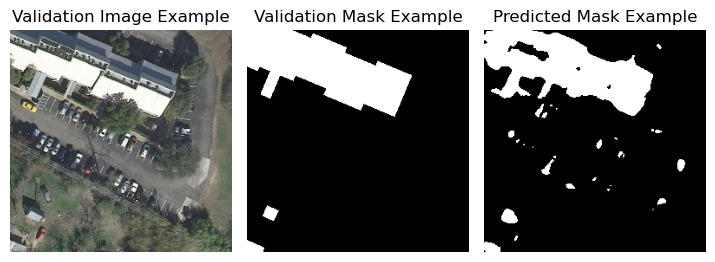

In [34]:
import matplotlib.pyplot as plt
import numpy as np

sample_id = 1  # or any index < len(X_val)

# Visualize the data and ground truth
plt.figure(figsize=(12, 4))

plt.subplot(1, 5, 3)
plt.imshow(X_val[sample_id])
plt.title("Validation Image Example")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(y_val[sample_id, :, :, 0], cmap="gray")
plt.title("Validation Mask Example")
plt.axis("off")

# Predict the mask for just one image
predicted_mask = model.predict(X_val[sample_id:sample_id+1])[0, :, :, 0]

# Calculate binary accuracy (assuming masks are binary: 0 and 1)
binary_pred = (predicted_mask > 0.5).astype(np.uint8)
accuracy = np.mean(binary_pred == y_val[sample_id, :, :, 0])

print(f"X_val shape: {X_val.shape}")
print(f"Model input shape: {model.input_shape}")
print(f"Accuracy of the predicted mask: {accuracy:.2f}")

# Show predicted mask
plt.subplot(1, 5, 5)
plt.imshow(predicted_mask > 0.5, cmap="gray")
plt.title("Predicted Mask Example")
plt.axis("off")

plt.tight_layout()
plt.show()


# What is Grad-CAM?

Grad-CAM (Gradient-weighted Class Activation Mapping) is a visualization technique used to interpret and understand the decisions made by CNNs. 

It highlights the regions in an input image that are most relevant for the model's predictions.

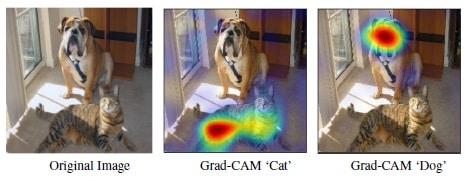

Grad-CAM works by:
1. Computing the gradients of the target class score with respect to the feature maps of the last convolutional layer.
2. Using these gradients to weight the importance of each feature map.
3. Generating a heatmap that shows the areas of the image that contributed most to the prediction.

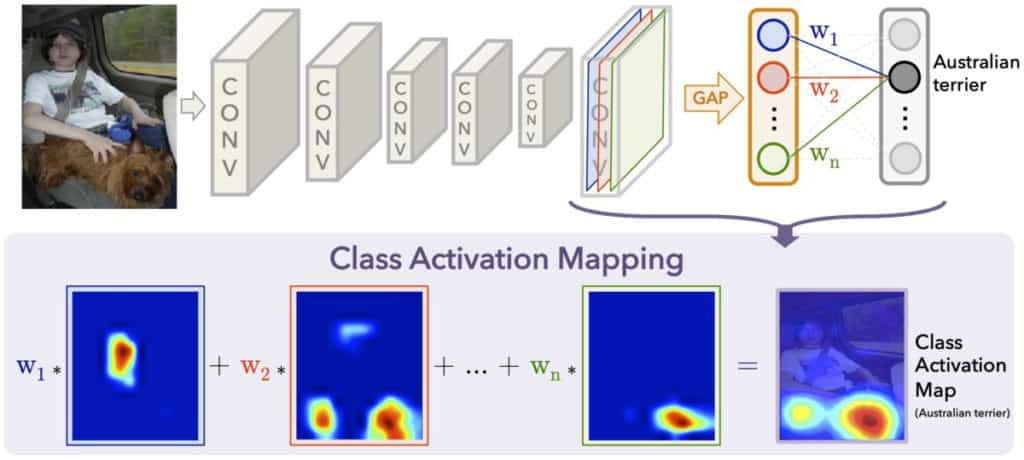

### Let's compute the activation map for our U-Net example

1/1 [==============================] - 0s 21ms/step


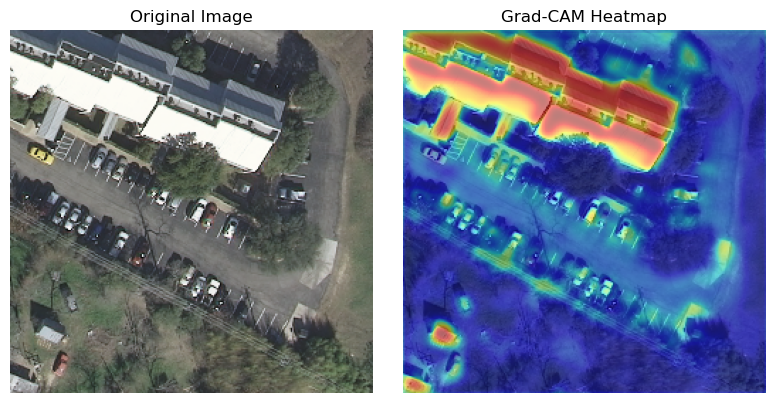

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the model's output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Forward pass: compute activations of the last convolutional layer and predictions
        conv_outputs, predictions = grad_model(img_array)
        # If no specific prediction index is provided, use the one with the highest score
        if pred_index is None:
            pred_index = tf.argmax(tf.reduce_mean(predictions, axis=(1, 2)))
            pred_index = pred_index.numpy().item()
        # Focus on the output channel corresponding to the predicted class
        class_channel = predictions[:, :, :, pred_index]

    # Compute the gradient of the predicted class with respect to the activations of the last conv layer
    grads = tape.gradient(class_channel, conv_outputs)
    # Pool the gradients over all spatial locations to get the importance of each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each feature map in the last convolutional layer by its corresponding importance weight
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to the range [0, 1] for visualization
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


# Sample image from validation set
sample_img = X_val[sample_id:sample_id+1]  # shape (1, 256, 256, 3)

# Force the model to build
_ = model.predict(sample_img)

# Automatically find the last Conv2D layer
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

# Generate Grad-CAM
heatmap = make_gradcam_heatmap(sample_img, model, last_conv_layer_name)

# Plot original image + heatmap
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_img[0])
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_img[0])
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.tight_layout()
plt.show()


Activation maps are highly useful in geospatial and environmental data science:

### 1. **Interpretability and Explainability**
- Activation maps highlight the regions of an image that a model focuses on when making predictions. This is crucial in geospatial and environmental applications, where understanding the "why" behind a model's decision is as important as the decision itself.
- For example, in land cover classification, activation maps can show which areas (e.g., forests, water bodies, urban regions) influenced the model's prediction, helping domain experts validate the model's reasoning.

### 2. **Model Debugging**
- Activation maps help identify whether a model is focusing on relevant features or being misled by irrelevant patterns (e.g., shadows, noise, or artifacts in satellite imagery).
- This can guide improvements in model architecture, training data quality, or preprocessing steps.

### 3. **Feature Localization**
- In tasks like building footprint extraction, flood mapping, or vegetation health assessment, activation maps can localize specific features of interest (e.g., buildings, flooded areas, or stressed vegetation) within high-resolution imagery.
- This spatial localization is critical for actionable insights, such as urban planning or disaster response.

### 4. **Trust and Transparency**
- In applications like disaster management or environmental monitoring, decisions based on geospatial data can have significant societal impacts. Activation maps provide transparency, building trust in AI models by showing how predictions are derived.

### 5. **Data Quality Assessment**
- Activation maps can reveal inconsistencies or biases in training data. For instance, if a model consistently focuses on irrelevant regions, it may indicate labeling errors or dataset imbalances.

### 6. **Policy and Decision Support**
- Activation maps can be used to communicate model outputs to non-technical stakeholders, such as policymakers or environmental managers, by visually demonstrating the areas of interest or concern.

### Example Applications:
- **Land Cover Classification**: Highlighting regions classified as forests, water bodies, or urban areas.
- **Disaster Management**: Identifying areas affected by floods, wildfires, or deforestation.
- **Urban Planning**: Extracting building footprints or road networks for infrastructure development.
- **Environmental Monitoring**: Detecting changes in vegetation health or water quality over time.

By providing spatial insights and interpretability, activation maps bridge the gap between complex AI models and real-world geospatial and environmental challenges.